### **Student Information**
Name: Lai Shao Hong

Student ID: 41223229L 

GitHub ID: shaohong722

Kaggle name: ShaoHong_72

Kaggle private scoreboard snapshot: 

![dm_private_rank.png](./pics/dm_private_rank.png)

---

# **Instructions**

For this lab we have divided the assignments into **three phases/parts**. The `first two phases` refer to the `exercises inside the Master notebooks` of the [DM2025-Lab2-Exercise Repo](https://github.com/difersalest/DM2025-Lab2-Exercise.git). The `third phase` refers to an `internal Kaggle competition` that we are gonna run among all the Data Mining students. Together they add up to `100 points` of your grade. There are also some `bonus points` to be gained if you complete `extra exercises` in the lab **(bonus 15 pts)** and in the `Kaggle Competition report` **(bonus 5 pts)**.

**Environment recommendations to solve lab 2:**
- **Phase 1 exercises:** Need GPU for training the models explained in that part, if you don't have a GPU in your laptop it is recommended to run in Colab or Kaggle for a faster experience, although with CPU they can still be solved but with a slower execution.
- **Phase 2 exercises:** We use Gemini's API so everything can be run with only CPU without a problem.
- **Phase 3 exercises:** For the competition you will probably need GPU to train your models, so it is recommended to use Colab or Kaggle if you don't have a laptop with a dedicated GPU.
- **Optional Ollama Notebook (not graded):** You need GPU, at least 4GB of VRAM with 16 GB of RAM to run the local open-source LLM models. 

## **Phase 1 (30 pts):**

1. __Main Exercises (25 pts):__ Do the **take home exercises** from Sections: `1. Data Preparation` to `9. High-dimension Visualization: t-SNE and UMAP`, in the [DM2025-Lab2-Master-Phase_1 Notebook](https://github.com/difersalest/DM2025-Lab2-Exercise/blob/main/DM2025-Lab2-Master-Phase_1.ipynb). Total: `8 exercises`. Commit your code and submit the repository link to NTU Cool **`BEFORE the deadline (Nov. 3th, 11:59 pm, Monday)`**

2. **Code Comments (5 pts):** **Tidy up the code in your notebook**. 

## **Phase 2 (30 pts):**

1. **Main Exercises (25 pts):** Do the remaining **take home exercises** from Section: `2. Large Language Models (LLMs)` in the [DM2025-Lab2-Master-Phase_2_Main Notebook](https://github.com/difersalest/DM2025-Lab2-Exercise/blob/main/DM2025-Lab2-Master-Phase_2_Main.ipynb). Total: `5 exercises required from sections 2.1, 2.2, 2.4 and 2.6`. Commit your code and submit the repository link to NTU Cool **`BEFORE the deadline (Nov. 24th, 11:59 pm, Monday)`**

2. **Code Comments (5 pts):** **Tidy up the code in your notebook**. 

3. **`Bonus (15 pts):`** Complete the bonus exercises in the [DM2025-Lab2-Master-Phase_2_Bonus Notebook](https://github.com/difersalest/DM2025-Lab2-Exercise/blob/main/DM2025-Lab2-Master-Phase_2_Bonus.ipynb) and [DM2025-Lab2-Master-Phase_2_Main Notebook](https://github.com/difersalest/DM2025-Lab2-Exercise/blob/main/DM2025-Lab2-Master-Phase_2_Main.ipynb) `where 2 exercises are counted as bonus from sections 2.3 and 2.5 in the main notebook`. Total: `7 exercises`. Commit your code and submit the repository link to NTU Cool **`BEFORE the deadline (Nov. 24th, 11:59 pm, Monday)`**

## **Phase 3 (40 pts):**

1. **Kaggle Competition Participation (30 pts):** Participate in the in-class **Kaggle Competition** regarding Emotion Recognition on Twitter by clicking in this link: **[Data Mining Class Kaggle Competition](https://www.kaggle.com/competitions/dm-lab-2-private-competition)**. The scoring will be given according to your place in the Private Leaderboard ranking: 
    - **Bottom 40%**: Get 20 pts of the 30 pts in this competition participation part.

    - **Top 41% - 100%**: Get (0.6N + 1 - x) / (0.6N) * 10 + 20 points, where N is the total number of participants, and x is your rank. (ie. If there are 100 participants and you rank 3rd your score will be (0.6 * 100 + 1 - 3) / (0.6 * 100) * 10 + 20 = 29.67% out of 30%.)   
    Submit your last submission **`BEFORE the deadline (Nov. 24th, 11:59 pm, Monday)`**. Make sure to take a screenshot of your position at the end of the competition and store it as `pic_ranking.png` under the `pics` folder of this repository and rerun the cell **Student Information**.

2. **Competition Report (10 pts)** A report section to be filled in inside this notebook in Markdown Format, we already provided you with the template below. You need to describe your work developing the model for the competition. The report should include a section describing briefly the following elements: 
* Your preprocessing steps.
* The feature engineering steps.
* Explanation of your model.

* **`Bonus (5 pts):`**
    * You will have to describe more detail in the previous steps.
    * Mention different things you tried.
    * Mention insights you gained. 

[Markdown Guide - Basic Syntax](https://www.markdownguide.org/basic-syntax/)

**`Things to note for Phase 3:`**

* **The code used for the competition should be in this Jupyter Notebook File** `DM2025-Lab2-Homework.ipynb`.

* **Push the code used for the competition to your repository**.

* **The code should have a clear separation for the same sections of the report, preprocessing, feature engineering and model explanation. Briefly comment your code for easier understanding, we provide a template at the end of this notebook.**

* Showing the kaggle screenshot of the ranking plus the code in this notebook will ensure the validity of your participation and the report to obtain the corresponding points.

After the competition ends you will have two days more to submit the `DM2025-Lab2-Homework.ipynb` with your report in markdown format and your code. Do everything **`BEFORE the deadline (Nov. 26th, 11:59 pm, Wednesday) to obtain 100% of the available points.`**

Upload your files to your repository then submit the link to it on the corresponding NTU Cool assignment.

## **Deadlines:**

![lab2_deadlines](./pics/lab2_deadlines.png)

**`From here on starts the code section for the competition.`**

---

# **Competition Code**

## **1. Preprocessing Steps**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import helpers.data_mining_helpers as dmh

In [2]:
#Read File

Data_Identification = pd.read_csv(r'.\data\kraggle\data_identification.csv')
Emotion = pd.read_csv(r'.\data\kraggle\emotion.csv')
Posts = pd.read_json(r'.\data\kraggle\final_posts.json',orient='records')
Posts = pd.json_normalize(Posts['root'])

In [3]:
#Rename Columns
Posts = Posts.rename(columns={'_type':'type',
                              '_source.post.post_id':'post_id',
                              '_source.post.text':'text',
                              '_source.post.hashtags':'hastags'
                              })

---

### **Understanding Data Distribution**

In [4]:
#Merging Data
Posts_Emotion = pd.merge(left=Posts,right=Emotion,left_on='post_id',right_on='id')

In [5]:
#Check NA
Posts_Emotion.isnull().apply(lambda x: dmh.check_missing_values(x))

,type,post_id,text,hastags,id,emotion
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0,0,0,0


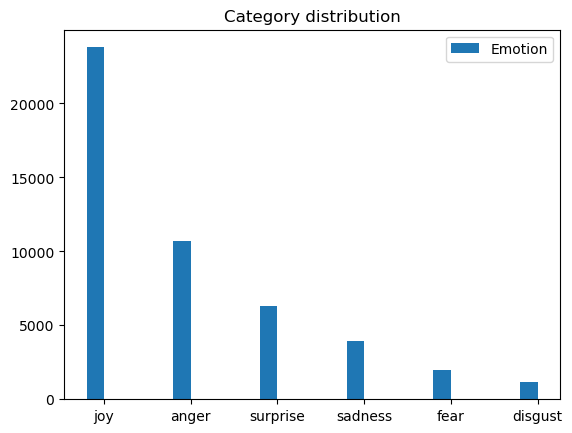

In [6]:
#Plot for understanding the distribution of data

w = 0.2
categories_ = np.arange(len(Posts_Emotion['emotion'].unique()))

fig,ax = plt.subplots()

ax.bar(categories_ - w/2, Posts_Emotion.emotion.value_counts(), width=w, label='Emotion')

ax.set_xticks(categories_)
ax.set_xticklabels(Posts_Emotion.emotion.value_counts().index)
ax.set_title('Category distribution')
ax.legend()

plt.show()

---

### **Cleaning Data**

I found that data have some pattern could be treated as one unique representations. 

1. Social Media Account : Changing to representation of [ACCOUNT]
2. Some emotion symbol which it will affect the tokenizer, such as <3 into "<" & "3". 
3. Some uncommon and unmeaningful data such as symbol ...

In [ ]:
Posts['text_clean'] = (
    Posts['text']
    .str.replace(r'(?<!\w)@[A-Za-z0-9_]{1,15}', '[NAME]', regex=True) # social media account
    .str.replace(r'[:()><]', '', regex=True) # symbol such as <3 , :D
    .str.replace(r'\.\.\.',' ',regex=True) # ...
    .str.replace(r'\\n',' ',regex=True)
    .str.strip()
)

---

## **2. Feature Engineering Steps**

### DistilBert Embedding

I use distilbert sentence embedding to tokenize and embedding my dataset into tension, which provide a deeper insight of how each sentence could be classify based on their embedding space.

In [5]:
# importing libraries
import random
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

In [6]:
random_seed = 42
random.seed(random_seed)

# Set a random seed for PyTorch (for GPU as well)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

In [7]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
model = AutoModel.from_pretrained('distilbert-base-uncased', output_hidden_states = True)
model.eval()

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [ ]:
from tqdm import tqdm

for i in tqdm(range(len(Posts))):

    text = Posts['text_clean'][i]

    encoding = tokenizer(
        [text],              
        padding=True,         
        truncation=True,      
        return_tensors='pt',  
        add_special_tokens=True
    )

    input_ids = encoding['input_ids']
    attention_mask = encoding['attention_mask']

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        word_embeddings = outputs.last_hidden_state   # (batch, seq, hidden)

    Posts.at[i, 'sentence_embedding'] = word_embeddings.mean(dim=1).tolist() ## data is store into column [sentence_embedding]

100%|██████████| 64171/64171 [26:28<00:00, 40.39it/s] 


In [ ]:
#Posts.to_pickle('.\data\kraggle\Posts_distilbert_embedding.pkl')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\laish\AppData\Local\Temp\ipykernel_29636\3653117225.py:1: SyntaxWarning: invalid escape sequence '\d'
  Posts.to_pickle('.\data\kraggle\Posts_distilbert_embedding.pkl')


---

## 3. Model Implementation Steps

In this report, I present how I use deep learning technique in classification task.

In [1]:
import pandas as pd

Posts = pd.read_pickle('.\data\kraggle\Posts_distilbert_embedding.pkl')
Data_Identification = pd.read_csv(r'.\data\kraggle\data_identification.csv')
Emotion = pd.read_csv(r'.\data\kraggle\emotion.csv')

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\laish\AppData\Local\Temp\ipykernel_31580\2212584367.py:3: SyntaxWarning: invalid escape sequence '\d'
  Posts = pd.read_pickle('.\data\kraggle\Posts_distilbert_embedding.pkl')


In [2]:
# Concat
#Identifying Train and Test id
Train_id = Data_Identification[Data_Identification['split']=='train']
Test_id = Data_Identification[Data_Identification['split']=='test']

#Splitting dataframe
Train_df = Posts[Posts['post_id'].isin(Train_id['id'])] # Train_id
Test_df = Posts[Posts['post_id'].isin(Test_id['id'])] #Test_id

In [3]:
Train_df = pd.merge(left=Train_df,right=Emotion,left_on='post_id',right_on='id',how='left')

In [4]:
## Duplicate some class with fewer data

sample = 4000

Small_df = Train_df[(Train_df['emotion'] != 'joy')&(Train_df['emotion'] != 'anger')]
Train_df = pd.concat([Train_df,Small_df.sample(n=sample)])

In [5]:
import numpy as np

X_train = np.vstack(Train_df['sentence_embedding'])
X_test = np.vstack(Test_df['sentence_embedding'])
Y_train = Train_df['emotion']

print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', Y_train.shape)
print('X_test.shape: ', X_test.shape)

X_train.shape:  (51890, 768)
y_train.shape:  (51890,)
X_test.shape:  (16281, 768)


### **Training : Deep Learning**

In [6]:
from sklearn.model_selection import train_test_split

#Split dataset for validations
DL_X_Train,DL_X_Test,DL_Y_Train,DL_Y_Test  = train_test_split(X_train, Y_train, test_size=0.1, random_state=42)

print('DL_X_train.shape: ', DL_X_Train.shape)
print('DL_y_train.shape: ', DL_Y_Train.shape)
print('DL_X_test.shape: ', DL_X_Test.shape)
print('DL_Y_test.shape: ',DL_Y_Test.shape)

DL_X_train.shape:  (46701, 768)
DL_y_train.shape:  (46701,)
DL_X_test.shape:  (5189, 768)
DL_Y_test.shape:  (5189,)


In [7]:
from sklearn.preprocessing import LabelEncoder

def label_encode(le, labels):
    enc = le.transform(labels)
    return keras.utils.to_categorical(enc)

def label_decode(le, one_hot_label):
    dec = np.argmax(one_hot_label, axis=1)
    return le.inverse_transform(dec)

label_encoder = LabelEncoder()
label_encoder.fit(DL_Y_Train)

LabelEncoder()

In [8]:
import keras

DL_Y_train_encode = label_encode(label_encoder, DL_Y_Train)
DL_Y_test_encode = label_encode(label_encoder, DL_Y_Test)

# I/O check
input_shape = DL_X_Train.shape[1]
print('input_shape: ', input_shape)

output_shape = len(label_encoder.classes_)
print('output_shape: ', output_shape)

input_shape:  768
output_shape:  6


In [20]:
from keras.models import Model
from keras.layers import Input, Dense
from keras.layers import ReLU, Softmax

# input layer
model_input = Input(shape=(input_shape, ))  # 768
X = model_input

# 1st hidden layer
X_W1 = Dense(units=650)(X)  # 64
H1 = ReLU()(X_W1)

# 2nd hidden layer
H1_W2 = Dense(units=600)(H1)  # 64
H2 = ReLU()(H1_W2)

# 3rd hidden layer
H2_W3 = Dense(units=550)(H2)  # 64
H3 = ReLU()(H2_W3)

# 4th hidden layer
H3_W4 = Dense(units=500)(H3)  # 64
H4 = ReLU()(H3_W4)

# 5th hidden layer
H4_W5 = Dense(units=450)(H4)  # 64
H5 = ReLU()(H4_W5)

# 6th hidden layer
H5_W6 = Dense(units=400)(H5)  # 64
H6 = ReLU()(H5_W6)

# 7th hidden layer
H6_W7 = Dense(units=350)(H6)  # 64
H7 = ReLU()(H6_W7)

# 8th hidden layer
H7_W8 = Dense(units=300)(H7)  # 64
H8 = ReLU()(H7_W8)

#8th hidden layer
H8_W9 = Dense(units=200)(H8)  # 64
H9 = ReLU()(H8_W9)

#9th hidden layer
H9_W10 = Dense(units=100)(H9)  # 64
H10 = ReLU()(H9_W10)

# output layer
H10_W11 = Dense(units=output_shape)(H10)  # 4
H11 = Softmax()(H10_W11)

model_output = H11

# create model
model = Model(inputs=[model_input], outputs=[model_output])

# loss function & optimizer
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# show model construction
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 650)            │       499,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 650)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 600)            │       390,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 550)            │       330,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_22 (ReLU)                 │ (None, 550)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 500)            │       275,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_23 (ReLU)                 │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 450)            │       225,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_24 (ReLU)                 │ (None, 450)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 400)            │       180,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_25 (ReLU)                 │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 350)            │       140,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_26 (ReLU)                 │ (None, 350)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 300)            │       105,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_27 (ReLU)                 │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_28 (ReLU)                 │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_29 (ReLU)                 │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 6)              │           606 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_6 (Softmax)             │ (None, 6)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,228,906 (8.50 MB)

 Trainable params: 2,228,906 (8.50 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from keras.callbacks import CSVLogger

csv_logger = CSVLogger('logs/kraggle_training_log.csv')

# training setting
epochs = 20
batch_size = 32

# training!
history = model.fit(DL_X_Train, DL_Y_train_encode, 
                    epochs=epochs, 
                    batch_size=batch_size, 
                    callbacks=[csv_logger],
                    validation_data = (DL_X_Test, DL_Y_test_encode))
print('training finish')

Epoch 1/20
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.5418 - loss: 1.2347 - val_accuracy: 0.5604 - val_loss: 1.1872
Epoch 2/20
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.5853 - loss: 1.1428 - val_accuracy: 0.5870 - val_loss: 1.1711
Epoch 3/20
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.5961 - loss: 1.1090 - val_accuracy: 0.5913 - val_loss: 1.1415
Epoch 4/20
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.6082 - loss: 1.0803 - val_accuracy: 0.5849 - val_loss: 1.1261
Epoch 5/20
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.6167 - loss: 1.0575 - val_accuracy: 0.5924 - val_loss: 1.1026
Epoch 6/20
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.6256 - loss: 1.0342 - val_accuracy: 0.5984 - val_loss: 1.1175
Epoch 7/20
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.6296 - loss: 1.0186 - val_accuracy: 0.6049 - val_loss: 1.0944
Epoch 8/20
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.6375 -

KeyboardInterrupt: 

In [22]:
import pandas as pd

training_log = pd.DataFrame()
training_log = pd.read_csv("logs/kraggle_training_log.csv")
training_log.head(5)

,epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.541809,1.234708,0.560416,1.187168
1,1,0.585255,1.142823,0.587011,1.171100
2,2,0.596069,1.109038,0.591251,1.141502
3,3,0.608167,1.080342,0.584891,1.126066
4,4,0.616689,1.057466,0.592407,1.102556


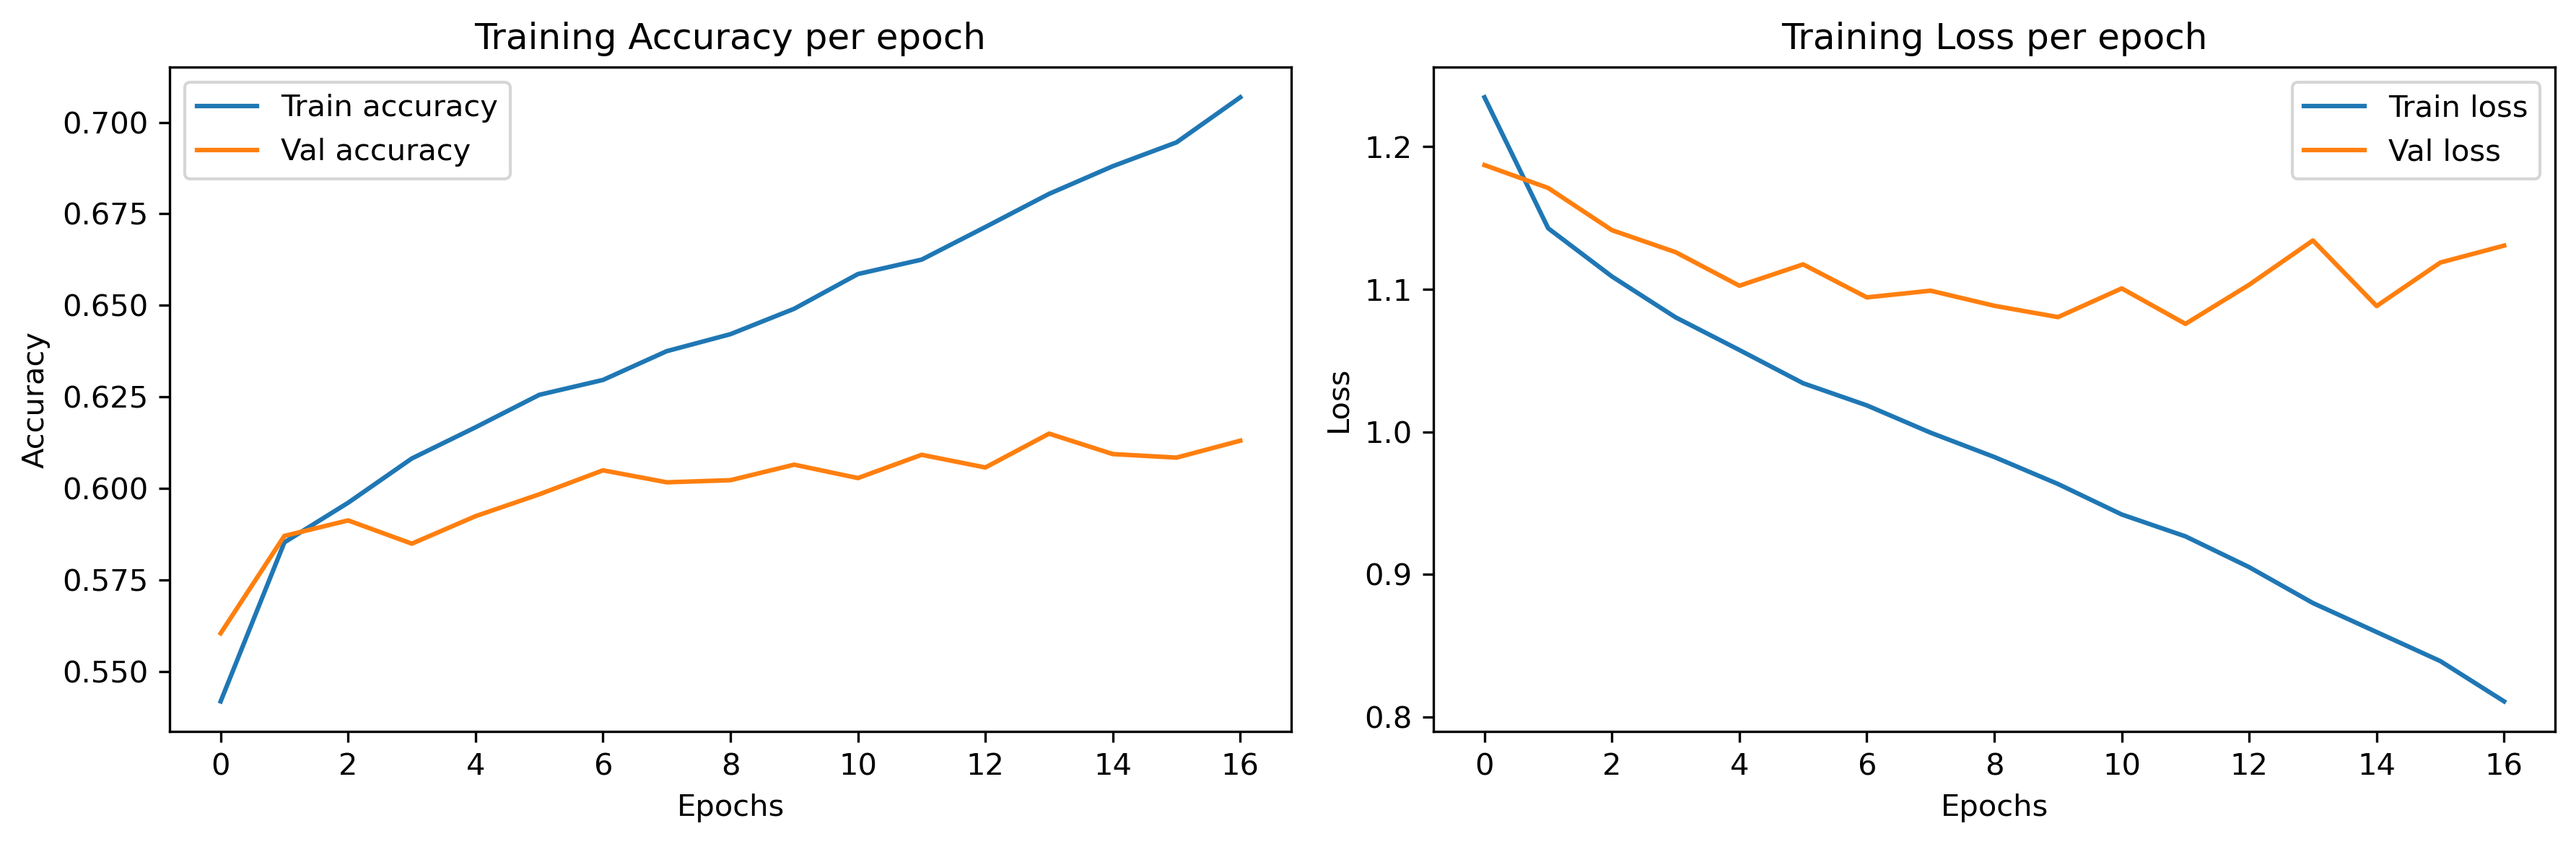

In [23]:
# Answer here
import matplotlib.pyplot as plt

epochs      = training_log['epoch']
train_acc   = training_log['accuracy']
val_acc     = training_log['val_accuracy']
train_loss  = training_log['loss']
val_loss    = training_log['val_loss']

fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=300)

# Accuracy
ax[0].plot(epochs, train_acc, label='Train accuracy')
ax[0].plot(epochs, val_acc,   label='Val accuracy')
ax[0].set_title('Training Accuracy per epoch')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Loss
ax[1].plot(epochs, train_loss, label='Train loss')
ax[1].plot(epochs, val_loss,   label='Val loss')
ax[1].set_title('Training Loss per epoch')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()

### Prediction

In [13]:
pred_result = model.predict(X_test, batch_size=128)
pred_result[:5]

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[1.3404335e-01, 1.5215768e-13, 8.6594933e-01, 7.1868658e-06,
        3.6604980e-08, 1.2110771e-09],
       [2.2648214e-01, 6.6736546e-05, 4.3132097e-02, 7.2680992e-01,
        3.0074103e-03, 5.0169678e-04],
       [1.4584142e-01, 1.3488014e-03, 1.2084105e-05, 8.4730625e-01,
        1.7388636e-03, 3.7525315e-03],
       [8.9340545e-03, 6.7800842e-04, 1.8128550e-05, 9.7888261e-01,
        1.1345154e-02, 1.4200096e-04],
       [6.7194209e-02, 5.1274979e-05, 1.8651578e-04, 6.4594632e-01,
        6.6208161e-02, 2.2041348e-01]], dtype=float32)

In [14]:
pred_result = label_decode(label_encoder, pred_result)

In [15]:
pred_result

array(['fear', 'joy', 'joy', ..., 'joy', 'joy', 'joy'],
      shape=(16281,), dtype=object)

### Plot Results Distribution

In [16]:
Prediction = pred_result

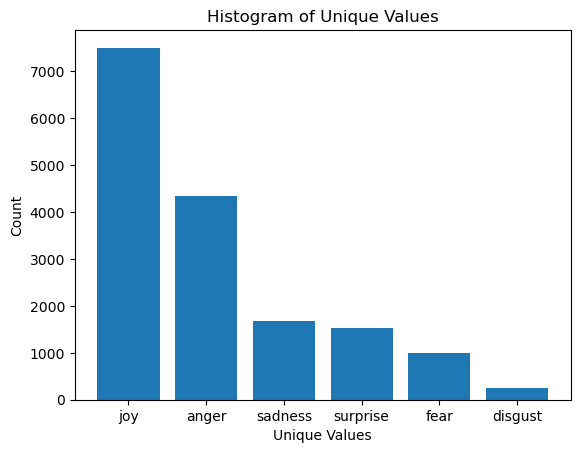

In [17]:
import matplotlib.pyplot as plt

unique_values, counts = np.unique(Prediction, return_counts=True)

sorted_indices = np.argsort(counts)[::-1]
unique_values = unique_values[sorted_indices]
counts = counts[sorted_indices]

# Create a histogram
plt.bar(unique_values, counts)

# Labeling the axes and title
plt.xlabel('Unique Values')
plt.ylabel('Count')
plt.title('Histogram of Unique Values')

# Show the plot
plt.show()

In [18]:
Check_df = pd.DataFrame({'text':Test_df['text_clean'].values,'emotion':Prediction})
Check_df.head(30)

,text,emotion
0,"We got the ranch, loaded our guns and sat up t...",fear
1,and that got my head bobbing a little bit.,joy
2,Same. Glad it's not just out store.,joy
3,Like always i will wait and see thanks for the...,joy
4,"There's a bit of room between ""not loving sub-...",joy
5,Okay I can see this looking really cool for a ...,joy
6,I screamed the chest pain was so bad i clutche...,fear
7,Fuck I love you prag,joy
8,"After this, I understand why outside Guangdong...",anger
9,Having a baby born too soon is #lifechanging 6...,joy


In [19]:
df_pred = pd.DataFrame({'id': Test_df['post_id'].values,'emotion': Prediction})
df_pred.to_csv('./kraggle_results/result_08_DistillBert_DL_LAST_2.csv', index=False) 

---

## 2. Bonus Section (5 pts Optional)

### 2.1 Mention Different Things You Tried

**1 Word2vec and Deleting Stop word**

The first idea come in my mind is to use keywords for classifications. Thus, I decided to use word2vec and remove 'stop words', hoping to only retain the embedding of keywords only and implement classifications.

I first try to train my own word2vec based on the dataset provided. Then, I directly put it into test and get a result of 0.45. Later on , I tried to use google model word2vec and get a result of 0.54. To remove 'stop words',i utilize the ``nltk`` package to remove stop word, hoping to only retain key meaningful words in classifications. The results drop unexpectedly to 0.52. 

**2 Bert Based Cased Embedding**

The next things I tried is using the model 'Bert Based Cased Embedding'. My idea is to get the sentence embedding of each sentence, which account the meaning of each sentence in embedding, to perform classification task. I have done research and tried to use it for the dataset. But i realized the model is too big, which the tension is too long, and exceed my laptop CPU. Thus after few tried I change to ``distillBert`` which the model is smaller while retaining the performance of Bert.

**3 SMOTE**

To solve class imbalance problem , I have utilize SMOTE for several time. I realized that SMOTE rarely improve the performace. Thus, I change to duplicate data that have fewer classes.

**4 XGBoost**

In [ ]:
#-----Compute Weight for embedding----------
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y = Train_df['emotion']
)

#-------Encoding For XGBoost----------
from sklearn.preprocessing import LabelEncoder

Encoder = LabelEncoder()
Y_train_encoded = Encoder.fit_transform(Y_train)

#-------XGBoost Training--------------
from xgboost import XGBClassifier

Model = XGBClassifier(random_state=42)

Model.fit(X_train, Y_train_encoded,sample_weight=sample_weights)
y_pred = Model.predict(X_test)

#------Decode Y Prediction-----------
y_pred_decode = Encoder.inverse_transform(y_pred)
y_pred_decode

Instead of Deep Learning, using XGBoost also provides great results. Other models I have tried include Logistic Regression which run the fastest, SVM.

Here I provide key approach I have tried throughout this competitions.

|Index|Data Preprocessing|Embedding|Data Imbalance Problem|Training Model|F1-Score|Addition Notes|
|-|-|-|-|-|-|-|
|1||Self-train word2vec||Logistic Regression|0.4492||
|2||Word2vec google model||Logistic Regression|0.5462||
|3|Deleting StopWord|Word2vec google model||Logistic Regression|0.5218||
|4|Deleting StopWord|Word2vec google model|SMOTE|Logistic Regression|0.5218||
|5||Word2vec google model|SMOTE|XGBoost|0.4854||
|6|Cleaning Text|DistillBerd Embedding||XGBoost|0.5910||
|7|Cleaning Text|DistillBerd Embedding|SMOTE|XGBoost|0.5980||
|8|Cleaning Text,Duplicate Small Ratio Data|DistillBerd Embedding|Sample Weight|XGBoost|0.6037||
|9|Cleaning Text|DistillBerd Embedding||SVM|0.6029|Run the longest|
|10|Cleaning Text|DistillBerd Embedding||Deep Learning|0.57|Epoch:100,Batch:25|
|11|Cleaning Text|DistillBerd Embedding||Deep Learning|0.60||

---

### 2.2 Mention Insights You Gained

**1. Differences between word2vec and transformer**

First insight I learn is the difference between word2vec and bert embedding. My first idea when starting classification is to use keywords for classifications. Thus, I decided to use word2vec and remove 'stop words', hoping to only retain the embedding of keywords and implement classifications. However, the results is only 0.52. 

To improve the results, I decided to use transformer embedding:"distillBert" with sentence embedding.Transformer will considered the meaning of particular words in a sentence. This provides more understanding on each sentence, and lastly get a better results on 0.60.

**2. SMOTE Restrictions**

Throughout this classifications class, class imbalance is one of the major problems I faced. One of the approach I use is SMOTE, however, SMOTE produce a new data in the mean distance between embedding based on particular class. This will create a more conservative cluster and depreciate the performance for model in classification. Most of my results drop when I used SMOTE. I have tried to directly duplicate the class that have fewer dataset which improve my model.